# PCA Example — From Scratch

This notebook walks through **Principal Component Analysis (PCA)** with the
custom implementation in `rice_ml.unsupervised_learning.pca`.

PCA is an **unsupervised dimensionality reduction method**. Its goal is to
replace a high-dimensional feature space with a smaller set of directions that
retain as much of the original variation as possible.

In this notebook, we will:

- load the Wine Quality dataset from a public source
- explore the data before applying PCA
- standardize the features
- fit PCA step by step
- examine explained variance and scree plots
- visualize the data in two principal components
- summarize what PCA helps us learn from the dataset


## Mathematical Intuition

Given a dataset represented by a feature matrix:

- Feature matrix:  
  `X ∈ ℝ^{n × d}`

PCA seeks a set of **orthonormal directions**  
`{v₁, v₂, …, v_k}` such that the projected data has **maximum variance**.

---

### Step 1: Mean Centering

Each feature is centered: `X_centered = X − μ`

where `μ` is the vector of feature-wise means.

---

### Step 2: Covariance Matrix

The covariance matrix is:

`Σ = (1 / (n − 1)) X_centeredᵀ X_centered`

---

### Step 3: Eigen-Decomposition

Solve:

`Σ v = λ v`

- `v` → principal directions (eigenvectors)
- `λ` → variance explained (eigenvalues)

---

### Step 4: Projection

Project data onto the top `k` eigenvectors:

`Z = X_centered V_k`

This yields a lower-dimensional representation while preserving variance.


## Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.unsupervised_learning.pca import PCA
from rice_ml.processing.pre_processing import standardize

## Dataset Description

The Wine Quality dataset contains physicochemical properties of red wines.
Each observation includes 11 continuous input variables such as acidity,
chlorides, sulphates, and alcohol content, along with a wine quality score.

Although PCA is unsupervised, this dataset is a good example because:

- the features are numeric
- there are several variables measured on different scales
- many variables are correlated


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Exploratory Data Analysis

Before fitting PCA, it is useful to look at the data structure.

In particular, we check:

- feature distributions
- differences in scale
- correlation patterns

Because PCA is driven by variance, preprocessing matters a lot.


### Feature Distributions

Looking at the marginal distribution of each variable helps us see:

- skewness
- possible outliers
- spread across variables
- whether some variables have much larger variation than others

Since PCA is a variance-based method, variables with larger scale can dominate
the components if we do not standardize first.


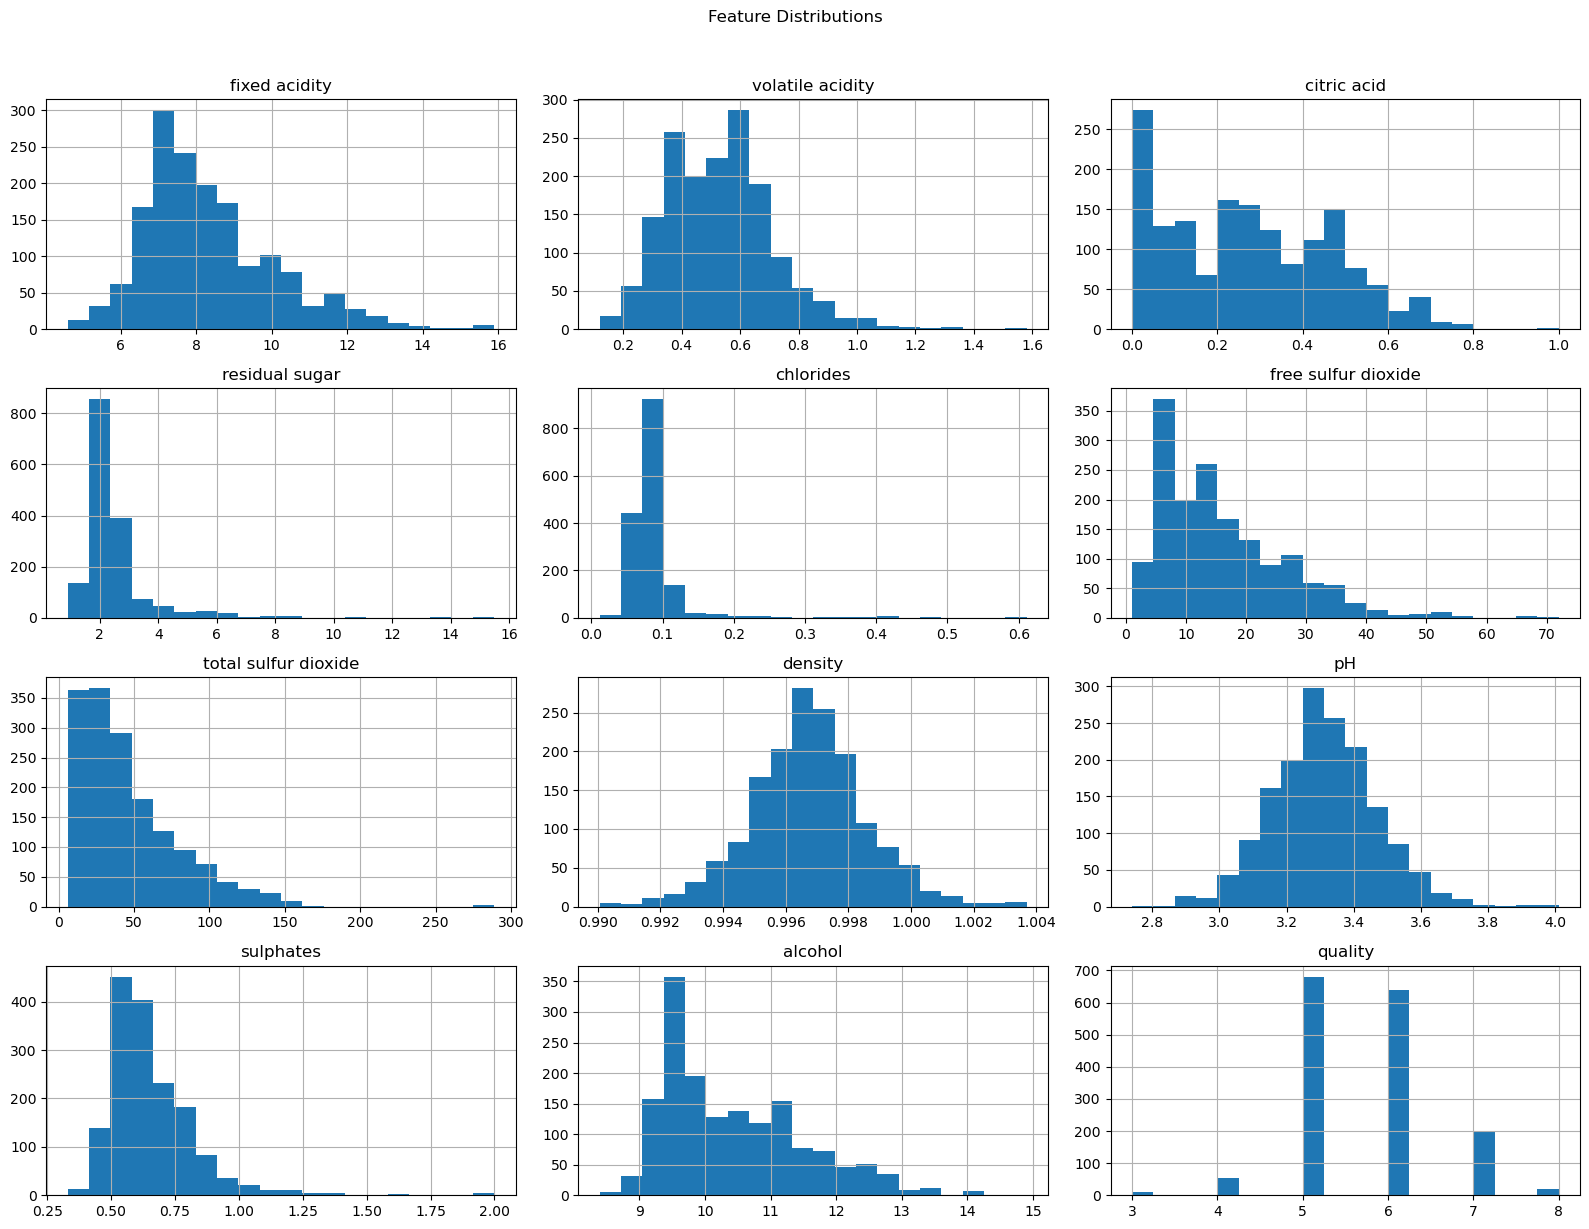

In [4]:
df.hist(figsize=(16, 12), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

### Summary Statistics

In [5]:
summary_stats = df.describe().T[["mean", "std", "min", "max"]]
summary_stats

,mean,std,min,max
fixed acidity,8.319637,1.741096,4.60000,15.90000
volatile acidity,0.527821,0.179060,0.12000,1.58000
citric acid,0.270976,0.194801,0.00000,1.00000
residual sugar,2.538806,1.409928,0.90000,15.50000
chlorides,0.087467,0.047065,0.01200,0.61100
free sulfur dioxide,15.874922,10.460157,1.00000,72.00000
total sulfur dioxide,46.467792,32.895324,6.00000,289.00000
density,0.996747,0.001887,0.99007,1.00369
pH,3.311113,0.154386,2.74000,4.01000
sulphates,0.658149,0.169507,0.33000,2.00000


### Correlation Structure

PCA is especially useful when several features move together.
A correlation matrix helps us see whether some variables may carry overlapping
information.


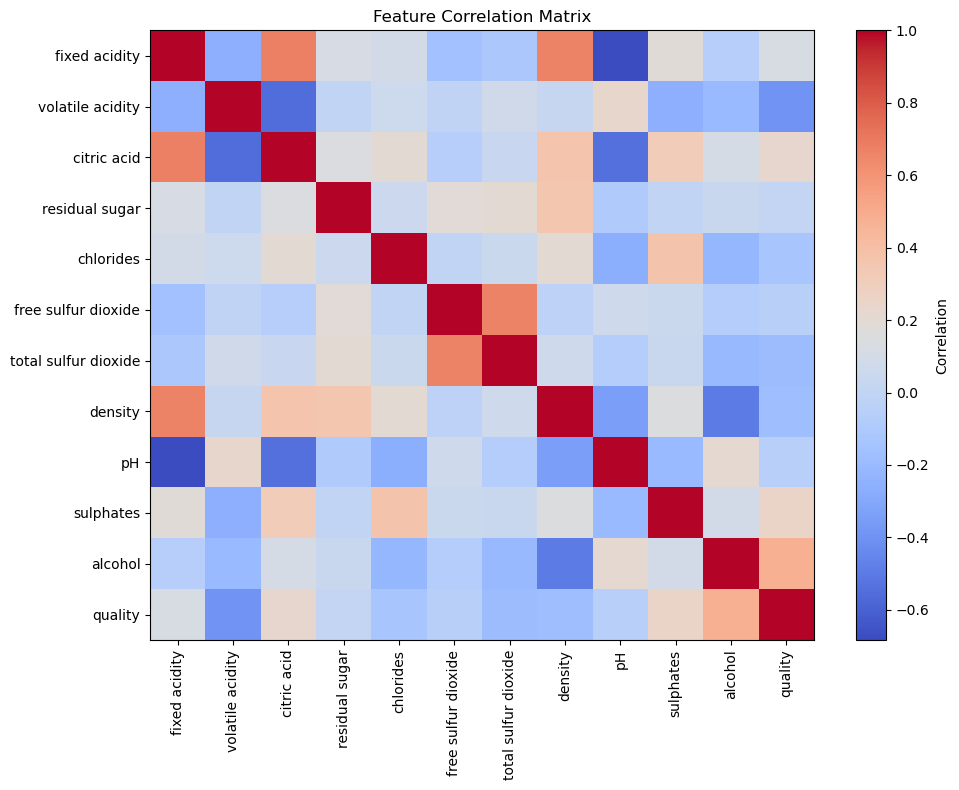

In [6]:
corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Prepare Features

In [7]:
X = df.values
feature_names = df.columns.tolist()

print("Shape of dataset:", X.shape)
print("Columns:", feature_names)

Shape of dataset: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


## Standardization

PCA is sensitive to feature scale, so we standardize the data before fitting
the model. This ensures that each feature contributes on a comparable basis.


In [8]:
X_std = standardize(X)

print("Mean of first standardized feature:", np.mean(X_std[:, 0]))
print("Std of first standardized feature:", np.std(X_std[:, 0]))

Mean of first standardized feature: 3.554935513496436e-16
Std of first standardized feature: 1.0


## Fit PCA on All Components

In [9]:
pca_full = PCA(n_components=X_std.shape[1])
X_pca_full = pca_full.fit_transform(X_std)

print("Explained Variance:", pca_full.explained_variance_)
print("Explained Variance Ratio:", pca_full.explained_variance_ratio_)
print("Total Explained Variance:", pca_full.explained_variance_ratio_.sum())

Explained Variance: [3.12312087 2.24328497 1.68397283 1.21578121 0.97387267 0.66300688
 0.61870473 0.50618912 0.41156493 0.3281246  0.18033141 0.05955516]
Explained Variance Ratio: [0.26009731 0.1868235  0.14024331 0.10125174 0.0811053  0.05521602
 0.05152648 0.04215605 0.03427563 0.02732662 0.01501822 0.00495983]
Total Explained Variance: 1.0


### Interpretation

Key observations from the explained variance ratios:

- the first few components explain a large share of total variance
- later components contribute much less
- most of the structure may be summarized in relatively few directions

This suggests that the data lies close to a lower-dimensional subspace and that
dimensionality reduction may be appropriate.


## Scree Plot Analysis

A scree plot shows how much variance each principal component explains.
It is commonly used to:

- identify diminishing returns across components
- choose a reasonable cutoff for dimensionality reduction
- visualize the effective dimensionality of the data


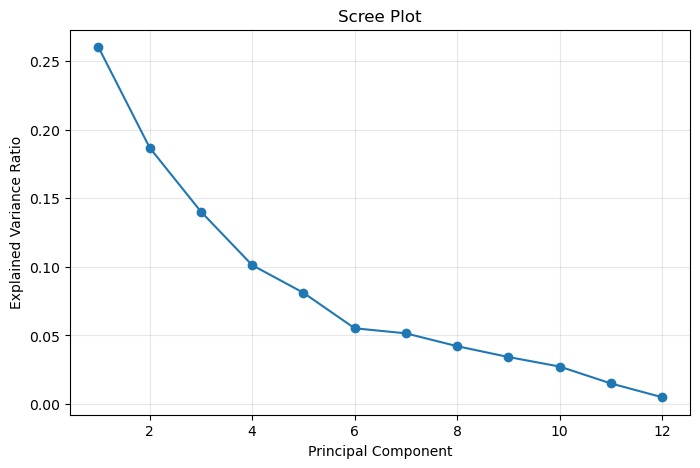

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True, alpha=0.3)
plt.show()

## Cumulative Explained Variance

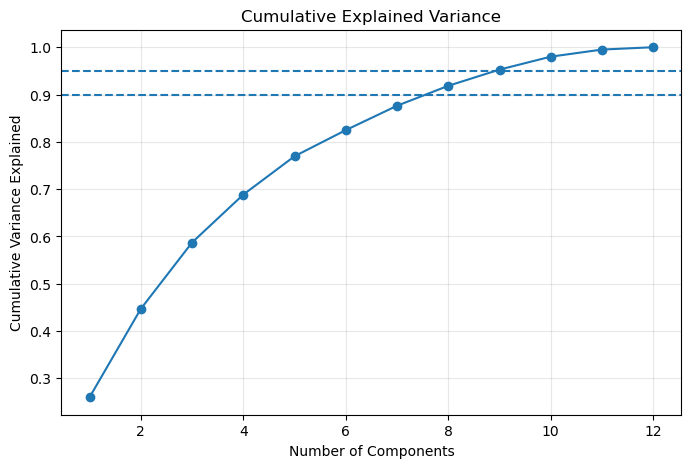

array([0.26009731, 0.44692081, 0.58716412, 0.68841586, 0.76952116,
       0.82473718, 0.87626366, 0.91841971, 0.95269534, 0.98002195,
       0.99504017, 1.        ])

In [11]:
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(y=0.90, linestyle="--")
plt.axhline(y=0.95, linestyle="--")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True, alpha=0.3)
plt.show()

cum_var

### Choosing a Smaller Number of Components

In practice, one common approach is to choose `k` by:

- keeping enough components to explain most of the variance
- locating the elbow in the scree plot
- selecting a small number of components for visualization

Next, we keep only two components so we can visualize the dataset in 2D.


In [12]:
# Fit PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

## 2D PCA Projection

To visualize the high-dimensional data, we project each observation onto the
first two principal components:

`Z = X_std W_{1:2}`

where:

- `X_std` is the standardized dataset
- `W_{1:2}` contains the first two principal directions

This gives a 2D view that captures the strongest sources of variation.


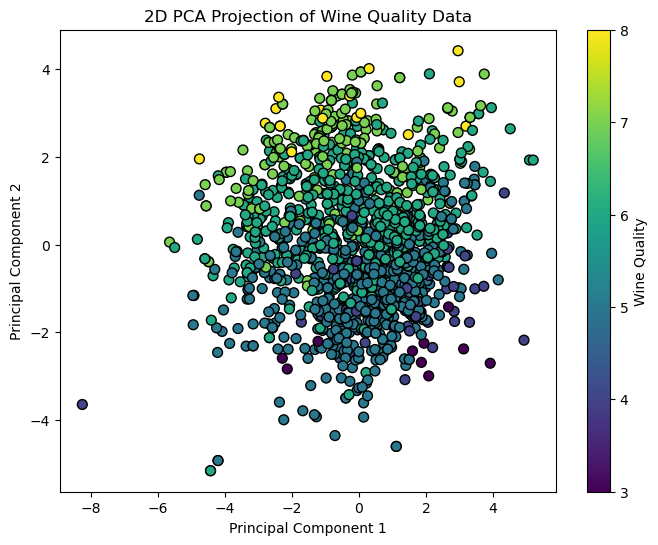

In [13]:
y = df["quality"].values

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    s=50
)
plt.colorbar(scatter, label="Wine Quality")
plt.title("2D PCA Projection of Wine Quality Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Principal Component Directions

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)
loadings

,PC1,PC2
fixed acidity,-0.487883,0.004173
volatile acidity,0.265129,-0.338968
citric acid,-0.473335,0.137358
residual sugar,-0.139154,-0.167736
chlorides,-0.197427,-0.189788
free sulfur dioxide,0.045881,-0.259483
total sulfur dioxide,-0.004067,-0.363971
density,-0.370301,-0.330781
pH,0.432721,0.065440
sulphates,-0.254535,0.109334


## Conclusion

### Results Summary

| Metric | Value |
|---|---|
| Original feature dimensions | 12 |
| Variance captured by PC1 | 26.01% |
| Variance captured by PC1 + PC2 | 44.69% |
| Components needed for 80% variance | 7 |
| Components needed for 90% variance | 9 |
| Components needed for 95% variance | 10 |

### Key Findings

- **The data does not collapse to a low-dimensional subspace.** PC1 alone
  captures only **26.01%** of the variance, and the first two components
  together account for just **44.69%**. To retain 90% of the variance, we
  need **9 of the 12 components** — meaning PCA achieves only modest
  dimensionality reduction on this dataset.

- **The 2D projection is useful for visualization, not summary.** Reducing
  to 2 components throws away more than half of the variation in the data
  (about 55%). The 2D scatter plot is a reasonable visualization tool for
  spotting overall structure, but it should not be treated as a faithful
  representation of the dataset.

- **Wine quality does not separate cleanly along PC1 or PC2.** The colored
  scatter plot shows that quality scores blend together across the
  principal-component space rather than forming distinct clusters. This is
  expected — PCA is unsupervised and optimizes for variance, not class
  separability. If the goal were to predict quality, a supervised method
  like logistic regression or a tree-based model would be more appropriate.

- **Standardization was essential.** Raw features differ by orders of
  magnitude (e.g. `total sulfur dioxide` reaches values in the dozens
  while `density` is near 1.0). Without standardization, PC1 would have
  been dominated almost entirely by `total sulfur dioxide`, giving a
  misleading picture of the data's structure.

- **The scree plot lacks a sharp elbow.** Variance explained decreases
  gradually from 26% → 19% → 14% → 10% → 8% → ... rather than dropping
  off suddenly. This means there isn't a clean "natural" cutoff for the
  number of components; the choice of `k` depends on what tradeoff
  between compression and fidelity is acceptable for the downstream task.

### Methodological Note

This notebook included the `quality` column in the feature matrix
when fitting PCA — i.e., PCA was run on all 12 columns, not just the
11 physicochemical predictors. In a typical workflow, you would
exclude the target before computing principal components and then
overlay it on the projection only for visualization. The effect on
this dataset is small (quality is weakly correlated with most features),
but in general it's good practice to drop the target before fitting
unsupervised methods.

### Limitations of PCA

- **Linear method only** — PCA can only capture linear correlations.
  If the wine-quality structure is governed by nonlinear interactions
  (which is plausible for chemistry data), PCA will miss it. Methods
  like t-SNE, UMAP, or kernel PCA can recover nonlinear structure.

- **Variance ≠ usefulness** — PCA preserves directions of largest
  variance, not directions that distinguish classes or predict outcomes.
  A direction with small variance may still be highly informative for
  downstream tasks.

- **Sensitive to outliers** — extreme values pull principal directions
  toward themselves because variance is squared distance from the mean.

- **Components are hard to interpret** — looking at the loadings table,
  PC1 and PC2 are linear combinations of all 11 predictors with various
  weights. They have no inherent meaning the way `alcohol` or `pH` do.

### Takeaway

PCA on the Wine Quality dataset produces a usable 2D visualization but
not a strong dimensionality reduction — most of the data's variation
is spread across many directions, and a 90% variance threshold requires
keeping 9 of 12 components. The notebook successfully demonstrates the
mechanics of PCA (centering, eigendecomposition, projection, scree
analysis), but the dataset's gradual variance decay is itself an
informative result: it tells us this data does not have a small set of
dominant latent factors.